In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
# Load dataset
data = pd.read_csv("/content/sentiment.csv")

# Show first 5 rows
data.head()

,s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   s.no                  23486 non-null  int64 
 1   age                   23486 non-null  int64 
 2   division_name         23472 non-null  object
 3   department_name       23472 non-null  object
 4   class_name            23472 non-null  object
 5   clothing_id           23486 non-null  int64 
 6   title                 19676 non-null  object
 7   review_text           22641 non-null  object
 8   alike_feedback_count  23486 non-null  int64 
 9   rating                23486 non-null  int64 
 10  recommend_index       23486 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [13]:
print(data.columns)
data.columns = data.columns.str.strip()

Index(['s.no', 'age', 'division_name', 'department_name', 'class_name',
       'clothing_id', 'title', 'review_text', 'alike_feedback_count', 'rating',
       'recommend_index'],
      dtype='object')


In [14]:
data['rating'].value_counts()

,count
rating,
5,13131
4,5077
3,2871
2,1565
1,842


In [15]:
#create sentiment column:
def create_sentiment(rating):
    if rating >= 4:
        return "positive"
    else:
        return "negative"

data['sentiment'] = data['rating'].apply(create_sentiment)

data['sentiment'].value_counts()

,count
sentiment,
positive,18208
negative,5278


In [17]:
#Text Preprocessing in Natural Language Processing (NLP)
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if isinstance(text, str):  # Make sure it's text
        text = text.lower()
        text = re.sub(r'[^a-zA-Z]', ' ', text)
        words = text.split()
        words = [word for word in words if word not in stop_words]
        return " ".join(words)
    else:
        return ""

In [19]:
data['cleaned_review'] = data['review_text'].apply(clean_text)
data.head()

,s.no,age,division_name,department_name,class_name,clothing_id,title,review_text,alike_feedback_count,rating,recommend_index,sentiment,cleaned_review
0,0,40,General,Bottoms,Jeans,1028,Amazing fit and wash,Like other reviewers i was hesitant to spend t...,0,5,1,positive,like reviewers hesitant spend much pair jeans ...
1,1,62,General Petite,Tops,Blouses,850,Lovely and unique!,As is true of a bunch of the fall clothing pho...,12,5,1,positive,true bunch fall clothing photos colors totally...
2,2,47,General Petite,Bottoms,Skirts,993,Meh,"I so wanted this skirt to work, love the desig...",3,1,0,negative,wanted skirt work love design way way long lb ...
3,3,45,General Petite,Bottoms,Pants,1068,Wow,Love love this! i was hesitant to buy this at ...,0,5,1,positive,love love hesitant buy first reviews made seem...
4,4,37,Initmates,Intimate,Swim,24,Great for bigger busts,I absolutely love the retro look of this swims...,0,5,1,positive,absolutely love retro look swimsuit first saw ...


In [20]:
#Convert Text to Numerical Features (TF-IDF Vectorization)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['cleaned_review'])
y = data['sentiment']

In [21]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (18788, 5000)
Testing size: (4698, 5000)


In [22]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
#Evaluate the Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8735632183908046

Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.57      0.67      1077
    positive       0.88      0.97      0.92      3621

    accuracy                           0.87      4698
   macro avg       0.86      0.77      0.80      4698
weighted avg       0.87      0.87      0.86      4698



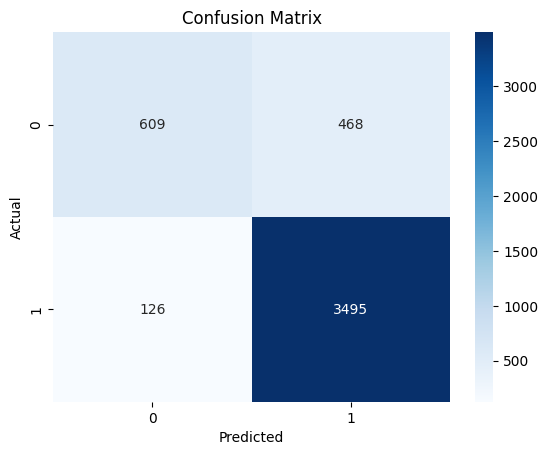

In [25]:
#Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
#Train Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.832907620263942


In [27]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8395061728395061


In [29]:
#Compare All Models Together
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8735632183908046
Naive Bayes Accuracy: 0.832907620263942
Random Forest Accuracy: 0.8395061728395061


In [31]:
import joblib


#Save Model
joblib.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']

In [32]:
#save vectorizer
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [33]:
#Create Prediction Function
def predict_sentiment(review):

    review_cleaned = clean_text(review)
    review_vectorized = vectorizer.transform([review_cleaned])

    prediction = model.predict(review_vectorized)

    return prediction[0]

In [34]:
#some customer review example statement
print(predict_sentiment("This product is amazing and I love it"))
print(predict_sentiment("Worst quality ever, very disappointed"))

positive
negative
